In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from data_loader import load_local_data

In [2]:
TICKERS = ['TSLA', 'BND', 'SPY']
data = load_local_data(TICKERS, save_dir='../data/processed')

prices = pd.concat([data['TSLA']['Close'], data['BND']['Close'], data['SPY']['Close']], axis=1)
prices.columns = ['TSLA', 'BND', 'SPY']
prices = prices.dropna()

daily_returns = prices.pct_change().dropna()

In [3]:
with open('../data/processed/portfolio_summary.json', 'r') as f:
    portfolio_summary = json.load(f)

strategy_weights = np.array([
    portfolio_summary['weights']['TSLA'],
    portfolio_summary['weights']['BND'],
    portfolio_summary['weights']['SPY']
])

benchmark_weights = np.array([0.0, 0.4, 0.6])  # TSLA, BND, SPY order

print("Strategy weights (TSLA/BND/SPY):", strategy_weights)
print("Benchmark weights (TSLA/BND/SPY):", benchmark_weights)

Strategy weights (TSLA/BND/SPY): [0. 0. 1.]
Benchmark weights (TSLA/BND/SPY): [0.  0.4 0.6]


In [4]:
backtest_returns = daily_returns.loc['2025-01-01':'2026-06-30']
print(f"Backtest period: {backtest_returns.index.min()} to {backtest_returns.index.max()}")
print(f"Trading days: {len(backtest_returns)}")

Backtest period: 2025-01-02 00:00:00 to 2026-06-29 00:00:00
Trading days: 372


In [5]:
strategy_daily = backtest_returns[['TSLA', 'BND', 'SPY']].dot(strategy_weights)
benchmark_daily = backtest_returns[['TSLA', 'BND', 'SPY']].dot(benchmark_weights)

strategy_cumulative = (1 + strategy_daily).cumprod()
benchmark_cumulative = (1 + benchmark_daily).cumprod()

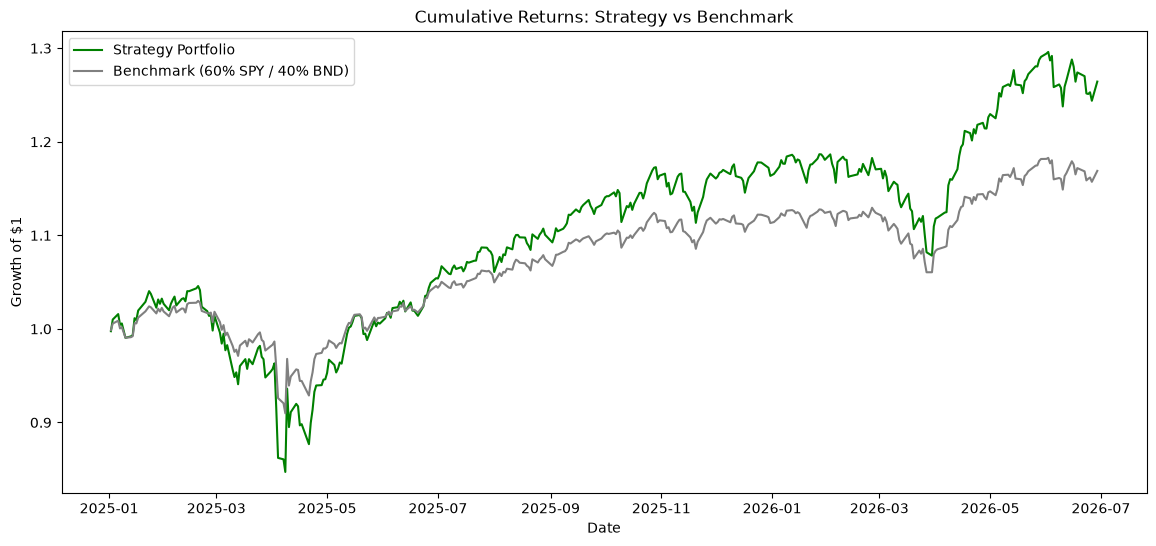

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(strategy_cumulative.index, strategy_cumulative, label='Strategy Portfolio', color='green')
plt.plot(benchmark_cumulative.index, benchmark_cumulative, label='Benchmark (60% SPY / 40% BND)', color='gray')
plt.title('Cumulative Returns: Strategy vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.show()

In [7]:
def performance_metrics(cumulative_returns, daily_returns_series, periods_per_year=252):
    total_return = cumulative_returns.iloc[-1] - 1
    n_years = len(cumulative_returns) / periods_per_year
    annualized_return = cumulative_returns.iloc[-1] ** (1 / n_years) - 1
    sharpe = (daily_returns_series.mean() / daily_returns_series.std()) * np.sqrt(periods_per_year)

    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    max_drawdown = drawdown.min()

    return {
        'Total Return (%)': round(total_return * 100, 2),
        'Annualized Return (%)': round(annualized_return * 100, 2),
        'Sharpe Ratio': round(sharpe, 3),
        'Max Drawdown (%)': round(max_drawdown * 100, 2)
    }

In [8]:
strategy_metrics = performance_metrics(strategy_cumulative, strategy_daily)
benchmark_metrics = performance_metrics(benchmark_cumulative, benchmark_daily)

results_df = pd.DataFrame([strategy_metrics, benchmark_metrics], index=['Strategy', 'Benchmark'])
results_df

,Total Return (%),Annualized Return (%),Sharpe Ratio,Max Drawdown (%)
Strategy,26.43,17.22,0.976,-19.00
Benchmark,16.89,11.15,0.999,-11.67


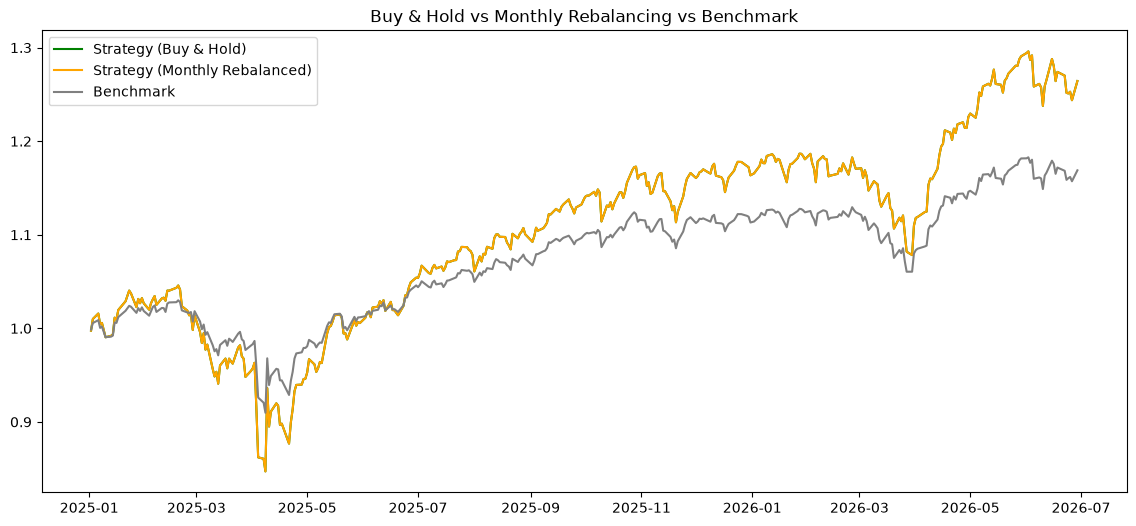

In [9]:
def simulate_monthly_rebalance(returns, target_weights, asset_order=('TSLA', 'BND', 'SPY')):
    returns = returns[list(asset_order)].copy()
    portfolio_value = [1.0]
    weights = target_weights.copy()
    current_month = None

    for date, row in returns.iterrows():
        if current_month != date.month:
            weights = target_weights.copy()  # rebalance to target at start of each month
            current_month = date.month
        day_return = np.dot(weights, row.values)
        portfolio_value.append(portfolio_value[-1] * (1 + day_return))
        weights = weights * (1 + row.values)
        weights = weights / weights.sum()

    return pd.Series(portfolio_value[1:], index=returns.index)

strategy_rebalanced = simulate_monthly_rebalance(backtest_returns, strategy_weights)

plt.figure(figsize=(14, 6))
plt.plot(strategy_cumulative.index, strategy_cumulative, label='Strategy (Buy & Hold)', color='green')
plt.plot(strategy_rebalanced.index, strategy_rebalanced, label='Strategy (Monthly Rebalanced)', color='orange')
plt.plot(benchmark_cumulative.index, benchmark_cumulative, label='Benchmark', color='gray')
plt.legend()
plt.title('Buy & Hold vs Monthly Rebalancing vs Benchmark')
plt.show()

### Conclusion & Reflection

The Strategy Portfolio (100% SPY, per the Max Sharpe recommendation from Task 4) outperformed the
Benchmark (60% SPY / 40% BND) on absolute return over the backtest period, delivering a **26.43% total
return** versus the benchmark's **16.89%**, and a **17.22% annualized return** versus **11.15%** — a
meaningful outperformance of roughly 6 percentage points annualized. However, on a risk-adjusted basis
the picture is more mixed: the Strategy's Sharpe ratio of **0.976** is actually slightly *lower* than
the Benchmark's **0.999**, and the Strategy experienced a deeper maximum drawdown of **-19.00%** compared
to the Benchmark's **-11.67%**. In other words, the Strategy's higher returns came with proportionally
higher risk and volatility, such that on a pure risk-adjusted basis the simple 60/40 benchmark was
essentially just as efficient — the two portfolios' Sharpe ratios are close enough that this outcome
is arguably a wash rather than a clear win for the model-driven approach.

This initial backtest suggests the model-driven strategy is not yet conclusively superior once risk is
accounted for, and several limitations temper any strong conclusion. First, this is a **single backtest
period** (Jan 2025-Jun 2026), which is too short to distinguish genuine skill from favorable market
conditions for SPY specifically during this window. Second, the simulation **does not account for
transaction costs** or rebalancing costs, which would erode the Strategy's edge further in practice.
Third, the portfolio weights were derived from Task 3's ARIMA forecast for TSLA, which — as shown by
the confidence interval widening to nearly 2x by the end of the horizon — carries substantial
uncertainty; the fact that the optimizer excluded TSLA entirely means this particular backtest result
is really just a statement about SPY vs. a SPY/BND blend, not a genuine test of the forecasting
pipeline's value-add. A more robust evaluation would require testing across multiple historical periods,
incorporating transaction costs, and validating whether the forecast-driven asset selection process
holds up when TSLA's expected return is not so extreme that it gets zeroed out entirely.